![Alt text](Reg_lin.png)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# 1- DataSet

In [28]:
# Generates a custom dataset with a continuous target variable
x, y = make_regression(n_samples= 100, n_features= 1, noise= 13)

(100, 1) (100,)
(100, 1) (100, 1)


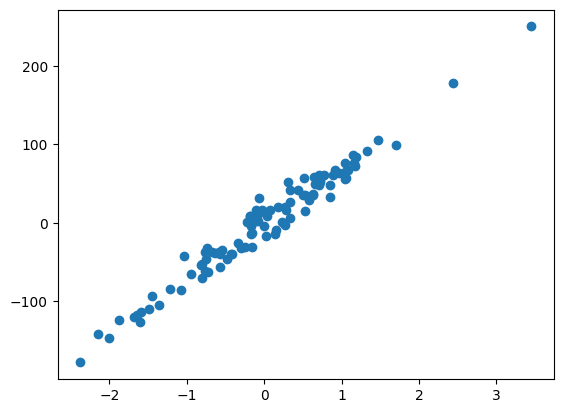

In [29]:
plt.scatter(x,y)
print(x.shape , y.shape)
# Fix the shape of y: make_regression outputs a flat array (n,). 
# We must reshape it into a proper matrix column (n, 1) so our math formulas execute correctly.
y =y.reshape(y.shape[0], 1)
print(x.shape , y.shape)

# 2- Matrix and Vectors Set Up

f(x) = aX + b ==> *F = X . Theta*

In [48]:
# X matrix:
once_matrix = np.ones(x.shape)
X = np.hstack((x,once_matrix))
X.shape

# Theta Vector:
Theta = np.random.randn(2,1)
print( "theta value is\n", Theta, "\nand it's shape is: ", Theta.shape)

theta value is
 [[ 1.41953369]
 [-0.52669283]] 
and it's shape is:  (2, 1)


# 3-Model

In [49]:
def model(X, Theta):
    return X.dot(Theta)

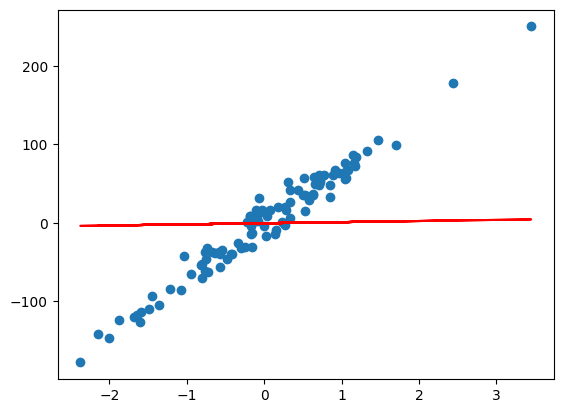

In [50]:
plt.scatter(x,y)
plt.plot(x, model(X,Theta), c='r')

# 4-Cost Function
**==>Means Squared Error**



![Alt text](images/MSE.png)

In [51]:
def cost_function(X, Theta, y):
    m = len(y)
    return 1/(2*m) * np.sum((model(X,Theta)-y)**2)

In [52]:
cost_function(X,Theta,y)

np.float64(2258.5545645851457)

# 5-Optimization Algorithm

**==>Gradient Descent**


**1-Gradient**


![Alt text](images/Gradient.png)

In [53]:
def Gradient(X,y,Theta):
    m= len(y)
    return (1/m)* X.T.dot(model(X,Theta)-y) 

**2-Gradient Descent**


![Alt text](images/Grad_Des.png)

In [64]:
def Gradient_Descent(X, y, Theta, learning_rate, iterations):
    cost_history = np.zeros(iterations)
    for i in range(0,iterations):
        Theta = Theta - learning_rate * Gradient(X,y,Theta)
        cost_history[i] = cost_function(X,Theta,y)
    return Theta , cost_history

# 6-Model training

In [65]:
theta_final, cost_history= Gradient_Descent(X=X, y=y, Theta=Theta, learning_rate= 0.001, iterations= 10000)

[[69.44124267]
 [ 0.24030367]]


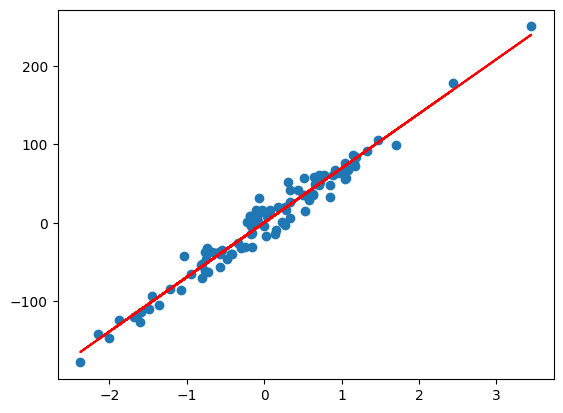

In [66]:
print(theta_final)
prediction= model(X=X, Theta= theta_final)
plt.scatter(x,y)
plt.plot(x,prediction, c='r')

# 7-Learning Curve

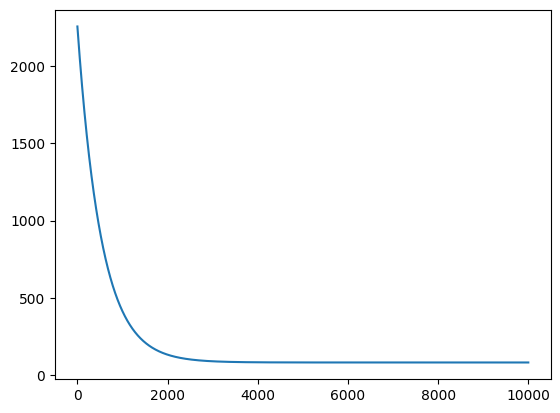

In [68]:
plt.plot(range(10000), cost_history)

# 8-The Coefficient of Determination

**It indicates how well a model fits data, with 1 being a perfect fit and 0 showing no explanatory power**

![Alt text](images/Det_Coef.png)

In [69]:
def coef_det(y, prediction):
    u= ((y - prediction)**2).sum()
    v= ((y - y.mean())**2).sum()
    return 1- u/v

In [79]:
Score = coef_det(y, prediction)
print(f"R-Squared Score: {Score:.4f}")
print(f"Mean Squared Error: {cost_function(X,theta_final,y)}")

R-Squared Score: 0.9651
Mean Squared Error: 82.07287882286676
